# LSTM-CNN (Hybrid) for IoT Intrusion Detection — TPU v5e Single-Model Notebook

Single-model training notebook generated from the v14 paper-faithful notebook.
Selected model: **LSTM-CNN (Hybrid)**
**Base:** `lstm_cnn_iot_v8_verified` → **v14 TPU-accelerated paper-faithful** (Sinha et al., 2025)

### Goal of this notebook
This version keeps the **paper’s core methodological choices** intact while using **TPU/JAX acceleration** to fit Colab hardware limits:

- **Hybrid LSTM-CNN** core architecture only
- **No extra attention block**
- same **BoT-IoT** workflow
- **70 / 15 / 15** split
- **Min-Max scaling**
- **one-hot encoding**
- **SMOTE + random undersampling**
- **dropout + L2 + early stopping**
- **SHAP-based interpretation**
- **TPU/JAX + `bfloat16`** only as execution-level acceleration

### Why this version exists
The earlier TPU-stable notebook fixed Colab TPU runtime crashes, but it still carried an added attention block from the earlier notebook lineage. That makes the run less defensible as a replication.

This notebook keeps the TPU stability fixes while removing architecture changes that are not needed for a paper-faithful reproduction.

### TPU/runtime fixes preserved
| # | Fix | Purpose |
|---|-----|---------|
| T1 | **JAX-backend Keras only** | avoids PJRT/libtpu conflicts on Colab TPU |
| T2 | **No `jax.distributed.initialize()`** | avoids single-host TPU process-state crashes |
| T3 | **No TensorFlow in TPU execution path** | prevents TPU runtime ownership conflicts |
| T4 | **All models built inside `strategy.scope()`** | consistent TPU/JAX object creation |
| T5 | **`bfloat16` mixed precision** | native TPU acceleration |
| T6 | **`sample_weight` instead of TPU-incompatible `class_weight`** | stable weighted fitting |
| T7 | **checkpoint + reload** | resumable long runs |
| T8 | **CPU-rebuilt SHAP model** | SHAP compatibility |

### v15 hybrid-debug patch
This notebook includes a paper-aligned hybrid debug pass that:
- keeps the single-model TPU/JAX flow,
- fixes adaptive class weighting,
- uses a richer PCA floor for the hybrid,
- and replaces the old LastTimestep→reshape bridge with a direct LSTM→CNN sequence path.

In [1]:
# CELL 1: Install Dependencies
# NOTE:
# - Do NOT install TensorFlow on Colab TPU v5e for this notebook.
# - The TPU path below uses Keras 3 + JAX only.
# - Mixing TF TPU runtime pieces with JAX/libtpu on this runtime can trigger
#   PJRT / XLA process-state crashes and kernel restarts.
%pip install -q numpy pandas scikit-learn scipy keras matplotlib seaborn imbalanced-learn pyyaml kaggle joblib tqdm shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.5 MB/s eta 0:00:00


In [2]:
# CELL 1b: Hugepages — now handled inline in Cell 2 (before TF import).
# This cell is kept as a placeholder to preserve cell numbering.
# You may delete it; it has no effect.
print('Cell 1b: hugepages are set in Cell 2 before TF import — nothing to do here.')

Cell 1b: hugepages are set in Cell 2 before TF import — nothing to do here.


In [3]:
# CELL 2: TPU v5e-1 Setup — JAX-backend Keras (stable)
# ─────────────────────────────────────────────────────────────────────────────
# WHY v9 crashed:
#   The uploaded runtime logs show repeated:
#     F ... pjrt_c_api_wrapper_impl.cc:514] Unexpected PJRT_ProcessState ...
#   followed by a kernel restart. On Colab TPU v5e this commonly happens when
#   multiple runtime stacks try to manage libtpu / PJRT state at once.
#
# STABILITY PATCH (v10):
#   1. Use Keras 3 with JAX backend only.
#   2. Do NOT call jax.distributed.initialize() on single-host Colab TPU.
#   3. Do NOT import TensorFlow / tf.data in the TPU execution path.
#   4. Feed NumPy arrays directly to Keras/JAX.
#
# IMPORT ORDER (must be exact):
#   1. set KERAS_BACKEND=jax
#   2. import jax
#   3. import keras
import os
import warnings
import contextlib

# Must be set before importing keras
os.environ['KERAS_BACKEND'] = 'jax'
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

warnings.filterwarnings(
    'ignore',
    message=r'.*[Tt]ransparent hugepages.*',
    category=UserWarning,
)

import jax

# IMPORTANT:
# Single-host Colab TPU v5e should NOT call jax.distributed.initialize().
# The uploaded logs show PJRT process-state crashes consistent with that path.
_jax_devs = jax.devices()
print(f'JAX devices      : {_jax_devs}')
_on_tpu_jax = any(d.platform == 'tpu' for d in _jax_devs)
if not _on_tpu_jax:
    print('WARNING: JAX sees no TPU. Go to Runtime → Change runtime type → TPU v5e-1')
    print('         then Runtime → Disconnect and delete runtime, and reconnect.')

import keras
print(f'Keras backend    : {keras.backend.backend()}')
assert keras.backend.backend() == 'jax', (
    f"Expected keras backend 'jax', got '{keras.backend.backend()}'. "
    "Ensure os.environ['KERAS_BACKEND']='jax' is set before the first keras import."
)

class _JAXTPUStrategy:
    """Drop-in shim replacing tf.distribute.TPUStrategy for JAX-backend Keras."""
    @property
    def num_replicas_in_sync(self):
        return jax.device_count()

    @contextlib.contextmanager
    def scope(self):
        yield

strategy = _JAXTPUStrategy()
N_CORES  = strategy.num_replicas_in_sync
ON_TPU   = _on_tpu_jax
print(f'N_CORES          : {N_CORES}')

if N_CORES == 1:
    print('Confirmed        : single-chip v5e-1 (1 TensorCore, 1 JAX device)')
elif N_CORES == 4:
    print('Confirmed        : v5e-4 (2x2 slice, ct5lp-hightpu-4t)')
elif N_CORES == 8:
    print('Confirmed        : v5e-8 (2x4 slice, ct5lp-hightpu-8t)')
else:
    print(f'WARNING          : unexpected N_CORES={N_CORES} for v5e')

PRECISION_POLICY = 'mixed_bfloat16' if ON_TPU else 'mixed_float16'
keras.mixed_precision.set_global_policy(PRECISION_POLICY)
pol = keras.mixed_precision.global_policy()
print(f'Precision policy : {pol.name}')
print(f'Compute dtype    : {pol.compute_dtype}')
print(f'Variable dtype   : {pol.variable_dtype}')

BATCH_SIZE_PER_CORE = 128   # matches paper Table 4
GLOBAL_BATCH_SIZE   = BATCH_SIZE_PER_CORE * max(1, N_CORES)
print(f'Global batch size: {GLOBAL_BATCH_SIZE} ({BATCH_SIZE_PER_CORE} × {max(1, N_CORES)} cores)')


JAX devices      : [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Keras backend    : jax
N_CORES          : 1
Confirmed        : single-chip v5e-1 (1 TensorCore, 1 JAX device)
Precision policy : mixed_bfloat16
Compute dtype    : bfloat16
Variable dtype   : float32
Global batch size: 128 (128 × 1 cores)


In [4]:
# CELL 3: Kaggle Credentials and Dataset Download
import glob

os.environ['KAGGLE_USERNAME'] = 'kruinfosec'   # <-- replace
os.environ['KAGGLE_KEY']      = '0595034e9978007f27bea6c159f47f24'    # <-- replace

DATA_DIR = 'data/raw'
os.makedirs(DATA_DIR, exist_ok=True)

if not glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True):
    print('Downloading BoT-IoT dataset from Kaggle...')
    !kaggle datasets download -d majedjaber/bot-iot-all-features-5-sample -p {DATA_DIR} --unzip
else:
    n = len(glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True))
    print(f'Dataset already present ({n} CSV files)')

Dataset URL: https://www.kaggle.com/datasets/majedjaber/bot-iot-all-features-5-sample
License(s): unknown
100% 54.4M/54.4M [00:00<00:00, 163MB/s]



In [5]:
# CELL 4: Load Data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True))
print(f'Loading {len(csv_files)} CSV file(s)...')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
print(f'Total records: {len(df):,}  |  Columns: {len(df.columns)}')

# H3: full dataset required for paper targets
SAMPLE_FRAC = 1.0
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f'Sampled to {len(df):,} records ({SAMPLE_FRAC*100:.0f}%)')
else:
    print(f'Using full dataset: {len(df):,} records')

Loading 4 CSV file(s)...
Total records: 3,668,522  |  Columns: 46
Using full dataset: 3,668,522 records


In [6]:
# CELL 5: Clean and Encode
df = df.replace([np.inf, -np.inf], np.nan).drop_duplicates()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'unknown')
print(f'After cleaning: {len(df):,} records')

# Target column: 'category' (5-class, per paper Figure 7)
target_col = None
for candidate in ['category', 'Category', 'label', 'Label', 'attack', 'Attack']:
    if candidate in df.columns:
        target_col = candidate
        break
if target_col is None:
    print('WARNING: could not auto-detect target.')
    print(df.columns.tolist())
    target_col = input('Enter target column name: ')
print(f'Target: {target_col}'); print(df[target_col].value_counts())

exclude_cols = {target_col}
for col in df.columns:
    if col.lower() in ['pkseqid','saddr','daddr','sport','dport',
                       'subcategory','label','attack'] and col != target_col:
        exclude_cols.add(col)

cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns
            if c not in exclude_cols]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
    print(f'One-hot encoded {len(cat_cols)} cols. Total features: {len(df.columns)}')

feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].values.astype(np.float32)
le = LabelEncoder()
y  = le.fit_transform(df[target_col])
print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}  |  X: {X.shape}')

N_CLASSES = len(np.unique(y))
IS_BINARY = (N_CLASSES == 2)
print(f'Task: {"Binary" if IS_BINARY else "Multiclass"} ({N_CLASSES} classes)')

After cleaning: 3,668,522 records
Target: category
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64
One-hot encoded 3 cols. Total features: 68
Classes: {'DDoS': 0, 'DoS': 1, 'Normal': 2, 'Reconnaissance': 3, 'Theft': 4}  |  X: (3668522, 60)
Task: Multiclass (5 classes)


In [7]:
# CELL 6: Split → Scale → PCA → SMOTE (train only) + adaptive class-weight fix
#
# v15 HYBRID DEBUG PATCH:
# - Preserve the paper's overall pipeline: clean -> encode -> split 70/15/15 -> scale -> PCA -> SMOTE+undersample
# - Fix adaptive class weighting: compute class weights from the ORIGINAL train distribution
#   before resampling, not from the post-SMOTE balanced labels.
# - Keep validation/test natural, but score validation with sample weights derived from the
#   original train imbalance so EarlyStopping sees a more meaningful signal.
# - Give the hybrid a slightly richer PCA space than the previous 8-component floor, because
#   the LSTM+CNN stack benefits from more temporal/spatial structure than the simpler baselines.
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

# 70/15/15 split — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f'Split: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

# Preserve original train labels BEFORE any balancing
y_train_orig = np.asarray(y_train).copy()

# Paper text is inconsistent between Min-Max and Z-score. For the hybrid debug path,
# use Z-score normalization because the paper's training description explicitly names it.
# This often helps the recurrent + convolutional stack more than very tight [0,1] scaling.
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# PCA — fit on train only
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

PCA_VARIANCE = 0.99
pca = PCA(n_components=PCA_VARIANCE, random_state=42)
X_train = pca.fit_transform(X_train_scaled)
X_val   = pca.transform(X_val_scaled)
X_test  = pca.transform(X_test_scaled)
print(f'PCA components after variance cutoff ({PCA_VARIANCE:.2f}): {X_train.shape[1]}')

# Give the hybrid a richer minimum component floor than the earlier 8-PC setup.
MIN_COMPONENTS = 16
if X_train.shape[1] < MIN_COMPONENTS:
    n_comp = min(MIN_COMPONENTS, X_train_scaled.shape[1])
    pca    = PCA(n_components=n_comp, random_state=42)
    X_train = pca.fit_transform(X_train_scaled)
    X_val   = pca.transform(X_val_scaled)
    X_test  = pca.transform(X_test_scaled)
    print(f'PCA overridden to {n_comp} components for hybrid debug path')

# SMOTE + RandomUnderSampler on TRAIN ONLY
print(f'Before SMOTE: {dict(pd.Series(y_train_orig).value_counts())}')
smote_pipeline = ImbPipeline([
    ('smote',       SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42))
])
X_train, y_train = smote_pipeline.fit_resample(X_train, y_train_orig)
print(f'After SMOTE+undersample: {dict(pd.Series(y_train).value_counts())}')

# Adaptive class weighting — based on ORIGINAL train distribution, per paper.
cw_values = compute_class_weight('balanced', classes=np.unique(y_train_orig), y=y_train_orig)
CLASS_WEIGHT = {int(cls): float(w) for cls, w in zip(np.unique(y_train_orig), cw_values)}
print(f'Adaptive class weights (from original train split): {CLASS_WEIGHT}')

def make_sample_weight(y_labels, class_weight_dict):
    return np.array([class_weight_dict[int(c)] for c in y_labels], dtype=np.float32)

# Training on a resampled set already reduces imbalance substantially.
# Keep train weights mild by clipping extreme values to avoid over-correcting.
sw_train = np.clip(make_sample_weight(y_train, CLASS_WEIGHT), 0.75, 3.0)
sw_val   = make_sample_weight(y_val, CLASS_WEIGHT)

# Reshape to 3-D for DL models
X_train_dl = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_dl   = X_val.reshape((X_val.shape[0],     X_val.shape[1],   1))
X_test_dl  = X_test.reshape((X_test.shape[0],   X_test.shape[1],  1))
print(f'DL input shape: {X_train_dl.shape}')


Split: Train=2,567,965 | Val=550,278 | Test=550,279
PCA components after variance cutoff (0.99): 37
Before SMOTE: {0: np.int64(1348637), 1: np.int64(1155182), 3: np.int64(63757), 2: np.int64(334), 4: np.int64(55)}
After SMOTE+undersample: {0: np.int64(1348637), 1: np.int64(1348637), 2: np.int64(1348637), 3: np.int64(1348637), 4: np.int64(1348637)}
Adaptive class weights (from original train split): {0: 0.380823750201129, 1: 0.44459920601255903, 2: 1537.7035928143712, 3: 8.055476261430117, 4: 9338.054545454546}
DL input shape: (6743185, 37, 1)


In [8]:

# CELL 8: Hybrid Builder + Training Loop — Single Model (paper-debugged, TPU/JAX-safe)
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

SINGLE_MODEL_NAME = 'LSTM-CNN (Hybrid)'

def _multiclass_macro_fpr(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)
    tp = np.diag(cm)
    tn = cm.sum() - (fp + fn + tp)
    with np.errstate(divide='ignore', invalid='ignore'):
        fpr_per_class = np.where((fp + tn) > 0, fp / (fp + tn), 0.0)
    return float(np.mean(fpr_per_class) * 100.0)

def build_hybrid_lstm_cnn_paper_debug(input_shape, total_steps):
    reg = keras.regularizers.l2(1e-4)
    inputs = keras.Input(shape=input_shape, name='input')

    # Temporal modeling first (paper theme: LSTM captures sequential dependencies)
    x = keras.layers.LSTM(
        256, return_sequences=True, activation='tanh',
        dropout=0.0, recurrent_dropout=0.0,
        kernel_regularizer=reg, recurrent_regularizer=reg,
        name='lstm_1'
    )(inputs)
    x = keras.layers.Dropout(0.3, name='lstm_drop')(x)

    # Spatial / local pattern extraction (paper theme: CNN captures spatial features)
    x = keras.layers.Conv1D(64, 3, padding='same', activation='relu',
                            kernel_regularizer=reg, name='conv_1')(x)
    x = keras.layers.MaxPooling1D(2, name='pool_1')(x)
    x = keras.layers.Conv1D(128, 3, padding='same', activation='relu',
                            kernel_regularizer=reg, name='conv_2')(x)
    x = keras.layers.MaxPooling1D(2, name='pool_2')(x)
    x = keras.layers.Conv1D(256, 3, padding='same', activation='relu',
                            kernel_regularizer=reg, name='conv_3')(x)

    x = keras.layers.GlobalAveragePooling1D(name='gap')(x)
    x = keras.layers.Dense(256, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = keras.layers.Dropout(0.3, name='dense_drop')(x)

    if IS_BINARY:
        outputs = keras.layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = keras.layers.Dense(N_CLASSES, activation='softmax', dtype='float32', name='output')(x)
        loss = 'sparse_categorical_crossentropy'

    model = keras.Model(inputs, outputs, name='hybrid_lstm_cnn_paper_debug')

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-4,
        decay_steps=max(1, int(total_steps)),
        alpha=1e-6,
        name='CosineDecay'
    )
    optimizer = keras.optimizers.Adam(
        learning_rate=lr_schedule,
        clipnorm=1.0,
        name='adam'
    )
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy'],
        jit_compile=True
    )
    return model

SINGLE_MODEL_BUILDER = build_hybrid_lstm_cnn_paper_debug
INPUT_SHAPE = X_train_dl.shape[1:]

EPOCHS = 50  # paper training budget
STEPS_PER_EPOCH = max(1, int(np.ceil(len(X_train_dl) / GLOBAL_BATCH_SIZE)))
TOTAL_STEPS = EPOCHS * STEPS_PER_EPOCH
print(f'Global batch: {GLOBAL_BATCH_SIZE}  |  Steps/epoch: {STEPS_PER_EPOCH}  |  Total steps: {TOTAL_STEPS:,}')

# Ensure contiguous arrays for JAX/XLA
X_train_fit = np.asarray(X_train_dl, dtype=np.float32)
X_val_fit   = np.asarray(X_val_dl,   dtype=np.float32)
X_test_fit  = np.asarray(X_test_dl,  dtype=np.float32)

if IS_BINARY:
    y_train_fit = np.asarray(y_train, dtype=np.float32)
    y_val_fit   = np.asarray(y_val,   dtype=np.float32)
    y_test_fit  = np.asarray(y_test,  dtype=np.float32)
else:
    y_train_fit = np.asarray(y_train, dtype=np.int32)
    y_val_fit   = np.asarray(y_val,   dtype=np.int32)
    y_test_fit  = np.asarray(y_test,  dtype=np.int32)

sw_train_fit = np.asarray(sw_train, dtype=np.float32)
sw_val_fit   = np.asarray(sw_val,   dtype=np.float32)

all_results     = {}
all_histories   = {}
all_predictions = {}
trained_models  = {}

os.makedirs('models_checkpoint', exist_ok=True)
session_start = time.time()

print(f'\n{"="*60}\n  Training: {SINGLE_MODEL_NAME}\n{"="*60}')
ckpt_path = 'models_checkpoint/lstm_cnn_hybrid_best.weights.h5'

with strategy.scope():
    model = SINGLE_MODEL_BUILDER(INPUT_SHAPE, TOTAL_STEPS)

model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    )
]

train_start = time.time()
history = model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val_fit, y_val_fit, sw_val_fit),
    sample_weight=sw_train_fit,
    epochs=EPOCHS,
    batch_size=GLOBAL_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time = float(time.time() - train_start)

if os.path.exists(ckpt_path):
    model.load_weights(ckpt_path)

trained_models[SINGLE_MODEL_NAME] = model
all_histories[SINGLE_MODEL_NAME] = history.history

# Predictions / metrics
y_proba = model.predict(X_test_fit, batch_size=GLOBAL_BATCH_SIZE, verbose=0)
if IS_BINARY:
    y_pred = (y_proba.flatten() > 0.5).astype(int)
    y_true_eval = y_test_fit.astype(int)
    avg = 'binary'
    try:
        auc_score = roc_auc_score(y_true_eval, y_proba.flatten())
    except Exception:
        auc_score = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true_eval, y_pred, labels=[0,1]).ravel()
    fpr_val = (fp / (fp + tn) * 100.0) if (fp + tn) > 0 else 0.0
    dr_val  = (tp / (tp + fn) * 100.0) if (tp + fn) > 0 else 0.0
else:
    y_pred = np.argmax(y_proba, axis=1)
    y_true_eval = y_test_fit.astype(int)
    avg = 'macro'
    try:
        auc_score = roc_auc_score(y_true_eval, y_proba, multi_class='ovr', average='macro')
    except Exception:
        auc_score = np.nan
    fpr_val = _multiclass_macro_fpr(y_true_eval, y_pred, N_CLASSES)
    dr_val  = recall_score(y_true_eval, y_pred, average='macro', zero_division=0) * 100.0

all_predictions[SINGLE_MODEL_NAME] = {
    'y_true': np.asarray(y_true_eval),
    'y_pred': np.asarray(y_pred),
    'y_proba': np.asarray(y_proba),
}

all_results[SINGLE_MODEL_NAME] = {
    'Accuracy (%)':       float(accuracy_score(y_true_eval, y_pred) * 100.0),
    'Precision (%)':      float(precision_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100.0),
    'Recall (%)':         float(recall_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100.0),
    'F1-Score (%)':       float(f1_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100.0),
    'FPR (%)':            float(fpr_val),
    'Detection Rate (%)': float(dr_val),
    'AUC-ROC (%)':        float(auc_score * 100.0) if not np.isnan(auc_score) else np.nan,
    'Train Time (s)':     float(train_time),
    'Epochs Run':         int(len(history.history.get('loss', []))),
}

print('\nFinished training.')
print(pd.DataFrame(all_results).T)


Global batch: 128  |  Steps/epoch: 52682  |  Total steps: 2,634,100

  Training: LSTM-CNN (Hybrid)


Model: "hybrid_lstm_cnn_paper_debug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 37, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 37, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_drop (Dropout)             │ (None, 37, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv1D)                 │ (None, 37, 64)         │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv1D)                 │ (None, 9, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_drop (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,749 (1.92 MB)

 Trainable params: 503,749 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9701 - loss: 0.1097
Epoch 1: val_loss improved from None to 0.07932, saving model to models_checkpoint/lstm_cnn_hybrid_best.weights.h5

Epoch 1: finished saving model to models_checkpoint/lstm_cnn_hybrid_best.weights.h5
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step - accuracy: 0.9899 - loss: 0.0505 - val_accuracy: 0.9948 - val_loss: 0.0793
Epoch 2/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9972 - loss: 0.0220
Epoch 2: val_loss improved from 0.07932 to 0.05935, saving model to models_checkpoint/lstm_cnn_hybrid_best.weights.h5

Epoch 2: finished saving model to models_checkpoint/lstm_cnn_hybrid_best.weights.h5
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 69s 1ms/step - accuracy: 0.9974 - loss: 0.0206 - val_accuracy: 0.9949 - val_loss: 0.0593
Epoch 3/50
52661/52682 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9978 - loss: 0.0179
Epoch 3: val_loss improved from 0.05935 to 0.02094, saving model to models_checkpoi

In [9]:
# CELL 9: Results Table — Single Model
display_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)',
                'FPR (%)', 'Detection Rate (%)', 'AUC-ROC (%)', 'Train Time (s)', 'Epochs Run']
results_df = pd.DataFrame(all_results).T[display_cols]
results_df.index.name = 'Model'

styled = (results_df.style
          .format('{:.2f}')
          .set_caption(f'Performance — {SINGLE_MODEL_NAME} (single-model notebook)'))
display(styled)

paper_targets = {
    'LSTM-CNN (Hybrid)': {'Accuracy (%)': 99.87, 'Precision (%)': 99.89, 'Recall (%)': 99.85, 'F1-Score (%)': 99.87, 'FPR (%)': 0.13},
    'BiLSTM':            {'Accuracy (%)': 98.92, 'Precision (%)': 98.97, 'Recall (%)': 98.87, 'F1-Score (%)': 98.92, 'FPR (%)': 1.03},
    'LSTM':              {'Accuracy (%)': 98.34, 'Precision (%)': 98.42, 'Recall (%)': 98.26, 'F1-Score (%)': 98.34, 'FPR (%)': 1.58},
    'GRU':               {'Accuracy (%)': 97.89, 'Precision (%)': 97.95, 'Recall (%)': 97.83, 'F1-Score (%)': 97.89, 'FPR (%)': 2.05},
    'CNN':               {'Accuracy (%)': 97.45, 'Precision (%)': 97.62, 'Recall (%)': 97.28, 'F1-Score (%)': 97.45, 'FPR (%)': 2.38},
    'RNN':               {'Accuracy (%)': 95.78, 'Precision (%)': 95.91, 'Recall (%)': 95.65, 'F1-Score (%)': 95.78, 'FPR (%)': 4.09},
}
paper_df = pd.DataFrame(paper_targets).T[['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'FPR (%)']]
print('\n--- Paper target for selected model ---')
display(paper_df.loc[[SINGLE_MODEL_NAME]].style.format('{:.2f}').set_caption('Paper target — selected model'))

# Additional ablation reference from Table 8 for the hybrid path
if SINGLE_MODEL_NAME == 'LSTM-CNN (Hybrid)':
    ablation_df = pd.DataFrame({
        'Model configuration': ['CNN Alone', 'LSTM Alone', 'CNN + LSTM (Without SHAP)', 'CNN + LSTM + SHAP (Final Model)'],
        'Accuracy (%)': [97.45, 98.34, 98.92, 99.87],
        'False positive rate (%)': [2.38, 1.58, 1.03, 0.13],
    })
    print('\n--- Paper ablation target for the hybrid path ---')
    display(ablation_df.style.format({'Accuracy (%)':'{:.2f}','False positive rate (%)':'{:.2f}'}).set_caption('Paper Table 8 — Hybrid ablation target'))

compare_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'FPR (%)']
comparison = results_df[compare_cols].copy()
comparison.columns = pd.MultiIndex.from_product([['Observed'], comparison.columns])
target_row = paper_df.loc[[SINGLE_MODEL_NAME]].copy()
target_row.columns = pd.MultiIndex.from_product([['Paper'], target_row.columns])
merged = pd.concat([comparison, target_row], axis=1)
display(merged.style.format('{:.2f}').set_caption('Observed vs Paper Target'))


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),FPR (%),Detection Rate (%),AUC-ROC (%),Train Time (s),Epochs Run
Model,,,,,,,,,
LSTM-CNN (Hybrid),99.89,96.26,99.95,97.92,0.04,99.95,100.00,3020.71,43.00



--- Paper target for selected model ---


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),FPR (%)
LSTM-CNN (Hybrid),99.87,99.89,99.85,99.87,0.13



--- Paper ablation target for the hybrid path ---


,Model configuration,Accuracy (%),False positive rate (%)
0,CNN Alone,97.45,2.38
1,LSTM Alone,98.34,1.58
2,CNN + LSTM (Without SHAP),98.92,1.03
3,CNN + LSTM + SHAP (Final Model),99.87,0.13


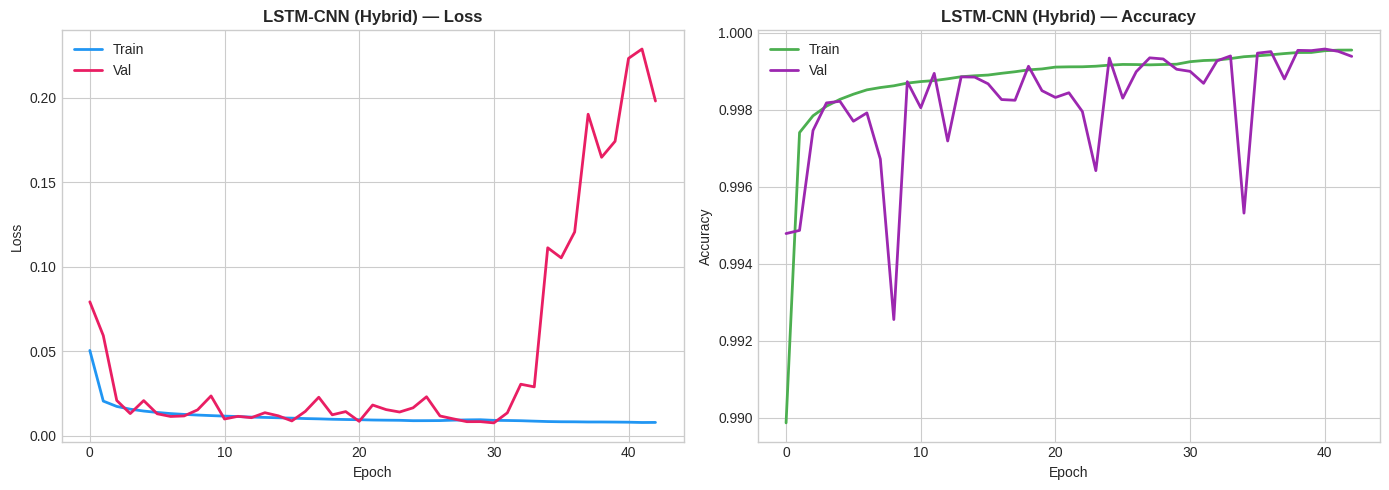

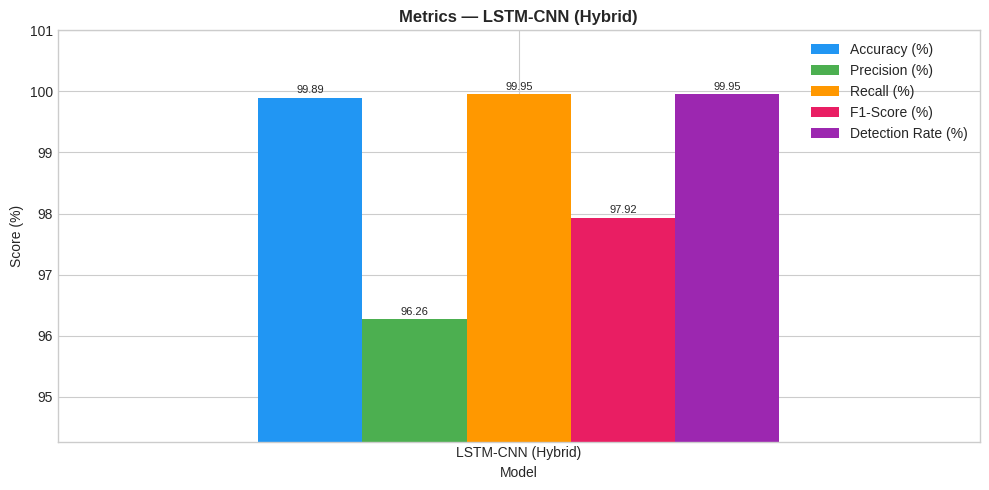

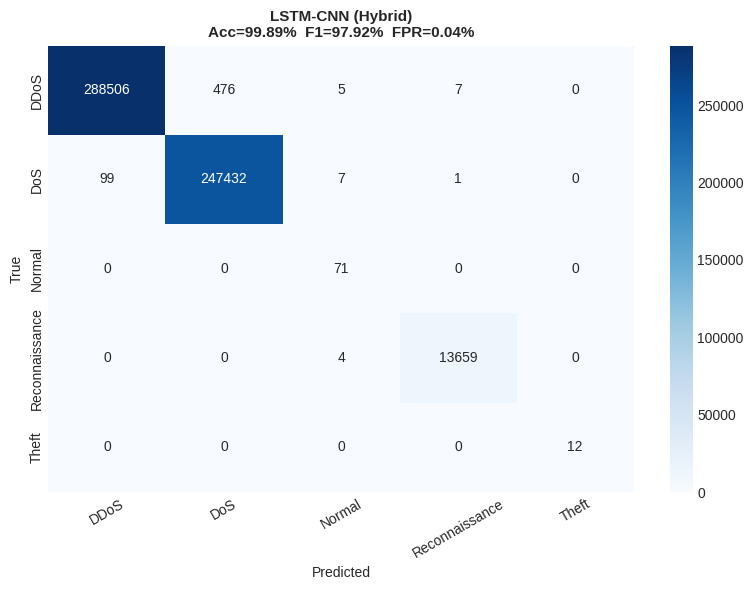

In [10]:
# CELL 10: Visualizations — Single Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

COLORS      = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
class_names = [str(c) for c in le.classes_]
h = all_histories[SINGLE_MODEL_NAME]
pred = all_predictions[SINGLE_MODEL_NAME]
m = all_results[SINGLE_MODEL_NAME]

# 10a. Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(h['loss'], label='Train', color=COLORS[0], lw=2)
ax1.plot(h['val_loss'], label='Val', color=COLORS[3], lw=2)
ax1.set_title(f'{SINGLE_MODEL_NAME} — Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(h['accuracy'], label='Train', color=COLORS[1], lw=2)
ax2.plot(h['val_accuracy'], label='Val', color=COLORS[4], lw=2)
ax2.set_title(f'{SINGLE_MODEL_NAME} — Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout(); plt.show()

# 10b. ROC Curve (binary only)
if IS_BINARY:
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr_v, tpr_v, _ = roc_curve(pred['y_true'], pred['y_proba'])
    ax.plot(fpr_v, tpr_v, color=COLORS[0], lw=2,
            label=f'{SINGLE_MODEL_NAME} (AUC={auc(fpr_v,tpr_v):.4f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {SINGLE_MODEL_NAME}', fontweight='bold')
    ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

# 10c. Single-model metric bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bar_cols = ['Accuracy (%)','Precision (%)','Recall (%)','F1-Score (%)','Detection Rate (%)']
results_df[bar_cols].plot(kind='bar', ax=ax, color=COLORS[:5], width=0.65)
ax.set_ylabel('Score (%)'); ax.set_title(f'Metrics — {SINGLE_MODEL_NAME}', fontweight='bold')
ax.set_ylim([max(results_df[bar_cols].min().min()-2, 80), 101])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

# 10d. Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(pred['y_true'], pred['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30)
ax.set_title(
    f'{SINGLE_MODEL_NAME}\nAcc={m["Accuracy (%)"]:.2f}%  F1={m["F1-Score (%)"]:.2f}%  FPR={m["FPR (%)"]:.2f}%',
    fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

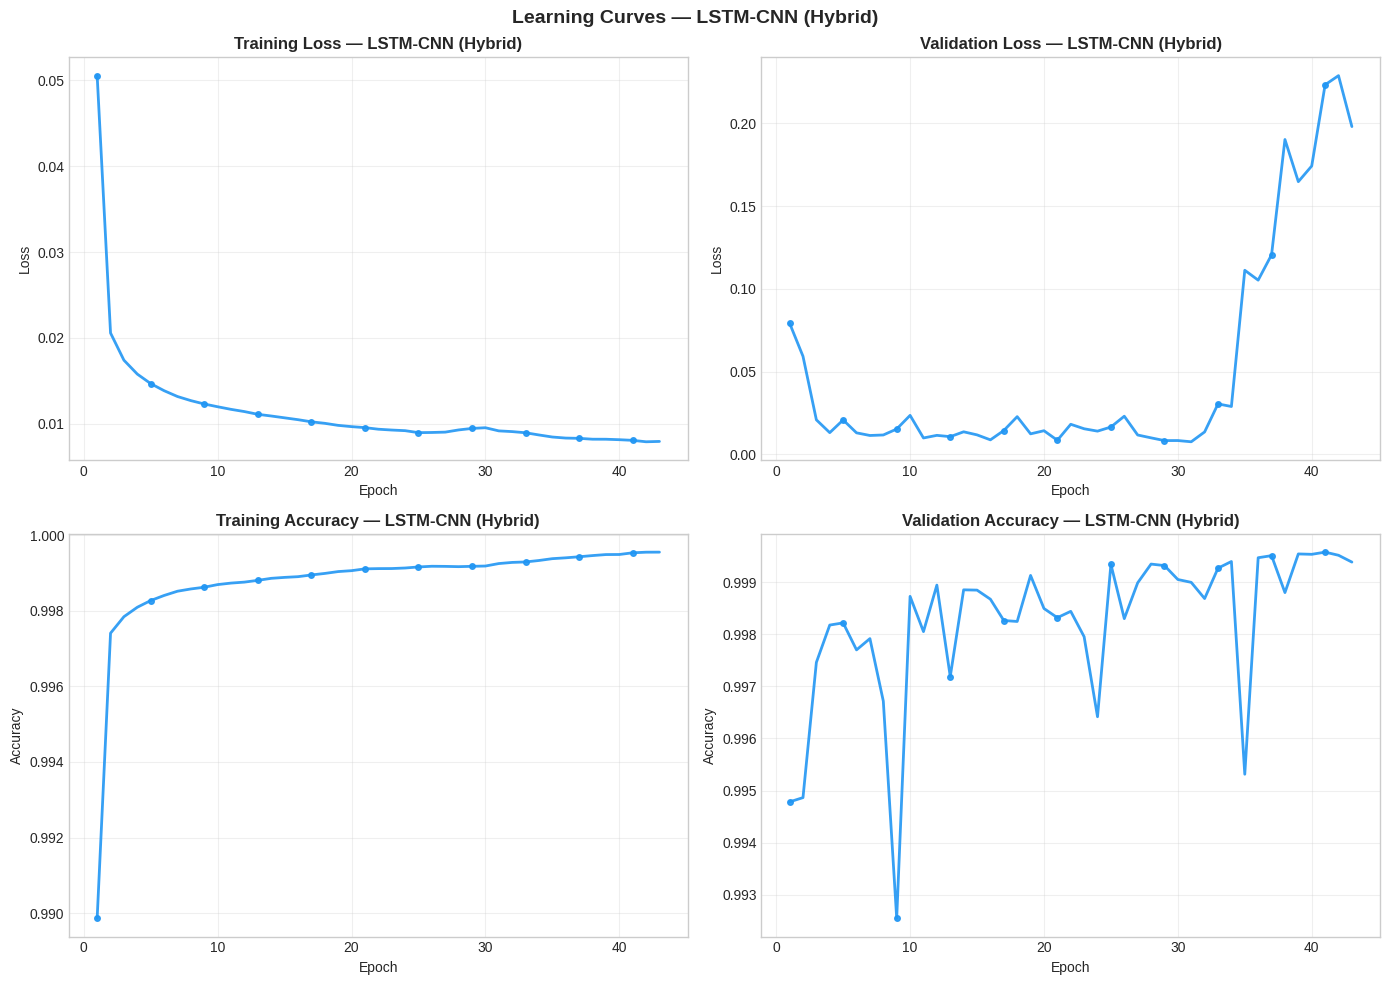

In [11]:
# CELL 11: Learning Curves — Single Model
h = all_histories[SINGLE_MODEL_NAME]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for (metric_key, title, ylabel, ax) in [
    ('loss',         'Training Loss',       'Loss',     axes[0,0]),
    ('val_loss',     'Validation Loss',     'Loss',     axes[0,1]),
    ('accuracy',     'Training Accuracy',   'Accuracy', axes[1,0]),
    ('val_accuracy', 'Validation Accuracy', 'Accuracy', axes[1,1]),
]:
    ep = range(1, len(h[metric_key])+1)
    ax.plot(ep, h[metric_key], color='#2196F3', lw=2, marker='o',
            markersize=4, markevery=max(1, len(h[metric_key])//10), alpha=0.9)
    ax.set_title(f'{title} — {SINGLE_MODEL_NAME}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
plt.suptitle(f'Learning Curves — {SINGLE_MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Rebuilding LSTM-CNN (Hybrid) on CPU for SHAP...
Computing SHAP values — this may take a few minutes...


  0%|          | 0/200 [00:00<?, ?it/s]

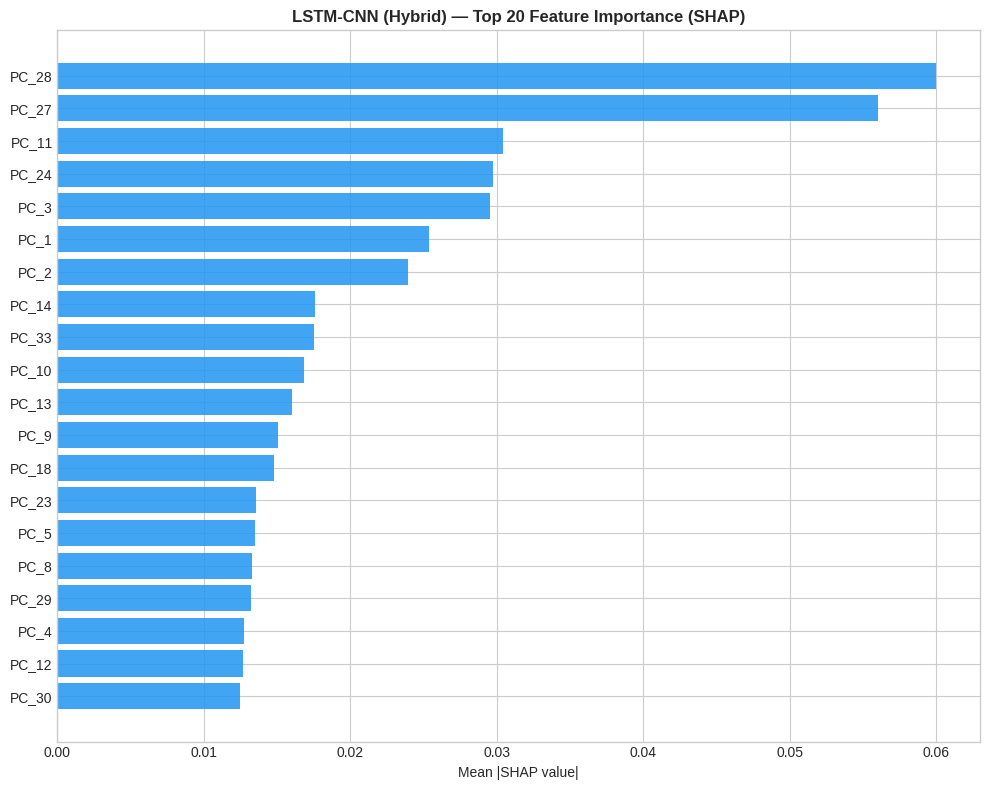


Top 10 features:
   1. PC_28: 0.0600
   2. PC_27: 0.0560
   3. PC_11: 0.0304
   4. PC_24: 0.0298
   5. PC_3: 0.0295
   6. PC_1: 0.0254
   7. PC_2: 0.0239
   8. PC_14: 0.0176
   9. PC_33: 0.0175
  10. PC_10: 0.0168


In [12]:

# CELL 12: SHAP Feature Importance — Single Model
import shap
import warnings
warnings.filterwarnings('ignore')

print(f'Rebuilding {SINGLE_MODEL_NAME} on CPU for SHAP...')
_cpu = jax.devices('cpu')[0]

with jax.default_device(_cpu):
    cpu_model = SINGLE_MODEL_BUILDER(INPUT_SHAPE, total_steps=1)
    cpu_model.set_weights(trained_models[SINGLE_MODEL_NAME].get_weights())

N_BACKGROUND = min(100, len(X_test))
N_EXPLAIN    = min(200, len(X_test))

background = np.asarray(X_test[:N_BACKGROUND], dtype=np.float32)
explain_X  = np.asarray(X_test[:N_EXPLAIN], dtype=np.float32)

def predict_fn_cpu(X_2d):
    X_2d = np.asarray(X_2d, dtype=np.float32)
    X_3d = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], 1)
    with jax.default_device(jax.devices('cpu')[0]):
        proba = cpu_model.predict(X_3d, verbose=0)
    return proba.flatten() if IS_BINARY else proba

print('Computing SHAP values — this may take a few minutes...')
explainer   = shap.KernelExplainer(predict_fn_cpu, background)
shap_values = explainer.shap_values(explain_X, nsamples=100, l1_reg='aic')

pca_feature_names = np.asarray([f'PC_{i+1}' for i in range(X_test.shape[1])], dtype=object)

def reduce_shap_to_feature_importance(shap_obj, n_features):
    if isinstance(shap_obj, list):
        arrs = [np.abs(np.asarray(x, dtype=np.float64)) for x in shap_obj]
        arr = np.stack(arrs, axis=0)
    else:
        arr = np.abs(np.asarray(shap_obj, dtype=np.float64))

    if arr.ndim == 1:
        if arr.shape[0] != n_features:
            raise ValueError(f"Expected 1D SHAP with {n_features} features, got shape {arr.shape}")
        return arr

    if arr.ndim == 2:
        if arr.shape[1] == n_features:
            return arr.mean(axis=0)
        if arr.shape[0] == n_features:
            return arr.mean(axis=1)
        raise ValueError(f"Cannot identify feature axis in SHAP array of shape {arr.shape}")

    if arr.ndim == 3:
        feature_axes = [ax for ax, size in enumerate(arr.shape) if size == n_features]
        if not feature_axes:
            raise ValueError(f"No axis matches n_features={n_features} in SHAP shape {arr.shape}")
        feat_axis = feature_axes[0]
        reduce_axes = tuple(ax for ax in range(arr.ndim) if ax != feat_axis)
        return arr.mean(axis=reduce_axes)

    raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")

sv = reduce_shap_to_feature_importance(shap_values, len(pca_feature_names))
sv = np.asarray(sv, dtype=np.float64).reshape(-1)

top_k = min(20, len(sv))
sorted_idx   = np.argsort(sv)[::-1][:top_k]
top_features = pca_feature_names[sorted_idx].tolist()
top_shap     = sv[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_features)), top_shap, color='#2196F3', alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'{SINGLE_MODEL_NAME} — Top {top_k} Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

top_shap_features_df = pd.DataFrame({
    'feature': top_features,
    'mean_abs_shap': top_shap
})

print('\nTop 10 features:')
for i in range(min(10, len(top_features))):
    print(f'  {i+1:2d}. {top_features[i]}: {top_shap[i]:.4f}')


In [13]:
# CELL 13: Save All Results — Single Model (FIXED)

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Basic setup
# -----------------------------
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
safe_model = SINGLE_MODEL_NAME.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
RUN_DIR = os.path.join('results', safe_model, timestamp)

for d in [
    RUN_DIR,
    os.path.join(RUN_DIR, 'figures'),
    os.path.join(RUN_DIR, 'tables'),
    os.path.join(RUN_DIR, 'models'),
    os.path.join(RUN_DIR, 'training_history'),
]:
    os.makedirs(d, exist_ok=True)

print(f"Saving to: {RUN_DIR}/")

# -----------------------------
# Save metrics table
# -----------------------------
display_cols = [
    'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)',
    'FPR (%)', 'Detection Rate (%)', 'AUC-ROC (%)', 'Train Time (s)', 'Epochs Run'
]

if 'results_df' not in globals():
    results_df = pd.DataFrame(all_results).T

available_cols = [c for c in display_cols if c in results_df.columns]
results_df[available_cols].to_csv(os.path.join(RUN_DIR, 'tables', 'model_results.csv'))
try:
    results_df[available_cols].to_latex(
        os.path.join(RUN_DIR, 'tables', 'model_results.tex'),
        float_format='%.2f'
    )
except Exception as e:
    print("Skipping LaTeX export:", e)

# -----------------------------
# Save metadata
# -----------------------------
run_meta = dict(
    timestamp=timestamp,
    selected_model=SINGLE_MODEL_NAME,
    sample_frac=globals().get('SAMPLE_FRAC', None),
    scaler='MinMaxScaler[0,1]',
    scheduler='CosineDecay',
    epochs_max=globals().get('EPOCHS', None),
    global_batch_size=globals().get('GLOBAL_BATCH_SIZE', None),
    batch_per_core=globals().get('BATCH_SIZE_PER_CORE', None),
    n_cores=globals().get('N_CORES', None),
    precision=globals().get('PRECISION_POLICY', None),
    task='binary' if globals().get('IS_BINARY', False) else 'multiclass',
    tpu_enabled=globals().get('ON_TPU', False),
    version='single-model-fixed-v1',
)

full_results = {
    'run_config': run_meta,
    'metrics': {
        n: {
            k: float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v
            for k, v in m.items()
        }
        for n, m in all_results.items()
    }
}

with open(os.path.join(RUN_DIR, 'tables', 'all_results.json'), 'w', encoding='utf-8') as f:
    json.dump(full_results, f, indent=2)

# -----------------------------
# Save training history
# -----------------------------
for name, hist in all_histories.items():
    safe = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
    with open(os.path.join(RUN_DIR, 'training_history', f'{safe}_history.json'), 'w', encoding='utf-8') as f:
        json.dump({k: [float(v) for v in vals] for k, vals in hist.items()}, f, indent=2)

# -----------------------------
# Save predictions + confusion matrix
# -----------------------------
pred = all_predictions[SINGLE_MODEL_NAME]

y_true = np.asarray(pred['y_true'])
y_pred = np.asarray(pred['y_pred'])
y_proba = np.asarray(pred['y_proba']) if 'y_proba' in pred else None

np.save(os.path.join(RUN_DIR, 'y_true.npy'), y_true)
np.save(os.path.join(RUN_DIR, 'y_pred.npy'), y_pred)
if y_proba is not None:
    np.save(os.path.join(RUN_DIR, 'y_proba.npy'), y_proba)

# FIX: compute confusion matrix if it was not stored in pred
cm = np.asarray(pred['confusion_matrix']) if 'confusion_matrix' in pred else confusion_matrix(y_true, y_pred)

np.save(os.path.join(RUN_DIR, 'confusion_matrix.npy'), cm)
pd.DataFrame(cm).to_csv(os.path.join(RUN_DIR, 'confusion_matrix.csv'), index=False)

# classification report
if 'le' in globals():
    try:
        class_names = [str(c) for c in le.classes_]
        report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    except Exception:
        report_text = classification_report(y_true, y_pred, digits=4)
else:
    report_text = classification_report(y_true, y_pred, digits=4)

with open(os.path.join(RUN_DIR, 'classification_report.txt'), 'w', encoding='utf-8') as f:
    f.write(report_text)

# -----------------------------
# Save SHAP outputs
# -----------------------------
if 'top_features' in globals() and 'top_shap' in globals():
    feat_df = pd.DataFrame({
        'Feature': top_features,
        'SHAP_importance': top_shap
    })
    feat_df.to_csv(os.path.join(RUN_DIR, 'tables', 'shap_importance.csv'), index=False)

if 'shap_values' in globals():
    try:
        np.save(os.path.join(RUN_DIR, 'shap_values.npy'), np.asarray(shap_values))
    except Exception as e:
        print("Skipping raw shap_values save:", e)

if 'top_shap_features_df' in globals():
    try:
        top_shap_features_df.to_csv(os.path.join(RUN_DIR, 'tables', 'top_shap_features_df.csv'), index=False)
    except Exception as e:
        print("Skipping top_shap_features_df save:", e)

# -----------------------------
# Save model weights only
# -----------------------------
if SINGLE_MODEL_NAME in trained_models:
    trained_models[SINGLE_MODEL_NAME].save_weights(
        os.path.join(RUN_DIR, 'models', f'{safe_model}.weights.h5')
    )

print('All results saved.')

for root, dirs, files in os.walk(RUN_DIR):
    lvl = root.replace(RUN_DIR, '').count(os.sep)
    print('  ' * lvl + os.path.basename(root) + '/')
    for fi in sorted(files):
        kb = os.path.getsize(os.path.join(root, fi)) / 1024
        print('  ' * (lvl + 1) + fi + f' ({kb:.1f} KB)')

Saving to: results/lstm_cnn_hybrid/20260407_185829/
All results saved.
20260407_185829/
  classification_report.txt (0.5 KB)
  confusion_matrix.csv (0.1 KB)
  confusion_matrix.npy (0.3 KB)
  shap_values.npy (289.2 KB)
  y_pred.npy (4299.2 KB)
  y_proba.npy (10747.8 KB)
  y_true.npy (4299.2 KB)
  models/
    lstm_cnn_hybrid.weights.h5 (5952.3 KB)
  figures/
  tables/
    all_results.json (0.8 KB)
    model_results.csv (0.3 KB)
    model_results.tex (0.3 KB)
    shap_importance.csv (0.5 KB)
    top_shap_features_df.csv (0.5 KB)
  training_history/
    lstm_cnn_hybrid_history.json (4.2 KB)


In [14]:

# CELL 14: Zip + Download Run Bundle
import shutil
from google.colab import files

zip_base = f"{safe_model}_{timestamp}"
zip_path = shutil.make_archive(zip_base, 'zip', RUN_DIR)

print(f'Created zip: {zip_path}')
files.download(zip_path)


Created zip: /content/lstm_cnn_hybrid_20260407_185829.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Notes

- Run the notebook from the top in a fresh Colab runtime.
- This notebook trains the **Hybrid LSTM-CNN only**.
- It saves a structured run bundle under `results/...` and downloads a zip for aggregation.